In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="6"

In [3]:
from aidan_lib.models.sam3_batched_img import SAM3BatchedImageHarness
import torch
from IPython.display import display

/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
harness = SAM3BatchedImageHarness(dtype=torch.bfloat16, model_compile=False)

Building SAM3 image model with torch.bfloat16 precision
Built model, now moving to device cuda with torch.bfloat16 precision
Finished loading model


In [5]:
from aidan_lib.definitions import DATA_DIR

In [6]:
imgs_dir = DATA_DIR / "imgs"
assert imgs_dir.exists()

In [7]:
img_1_path = imgs_dir / "all.png"
img_2_path = imgs_dir / "thompson.png"

In [8]:
from PIL import Image

In [9]:
img_1 = Image.open(img_1_path).convert("RGB")
img_2 = Image.open(img_2_path).convert("RGB")

In [18]:
out = harness([img_1, img_2], "Person")

(1008, 1008) (1372, 866)
(1008, 1008) (1454, 1150)


In [19]:
mask_img = Image.fromarray(out[0].masks[0].cpu().numpy())
mask_img_2 = Image.fromarray(out[1].masks[0].cpu().numpy())

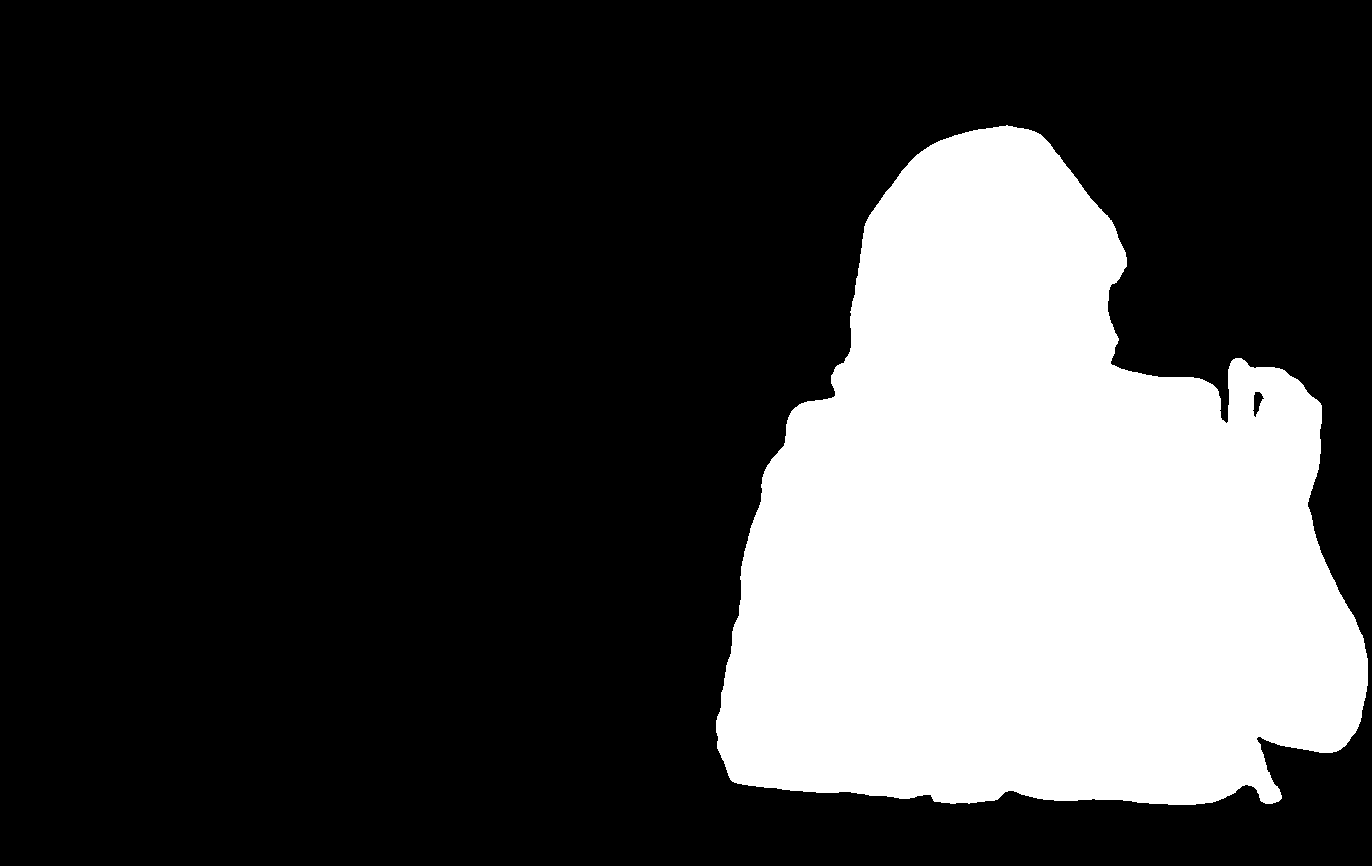

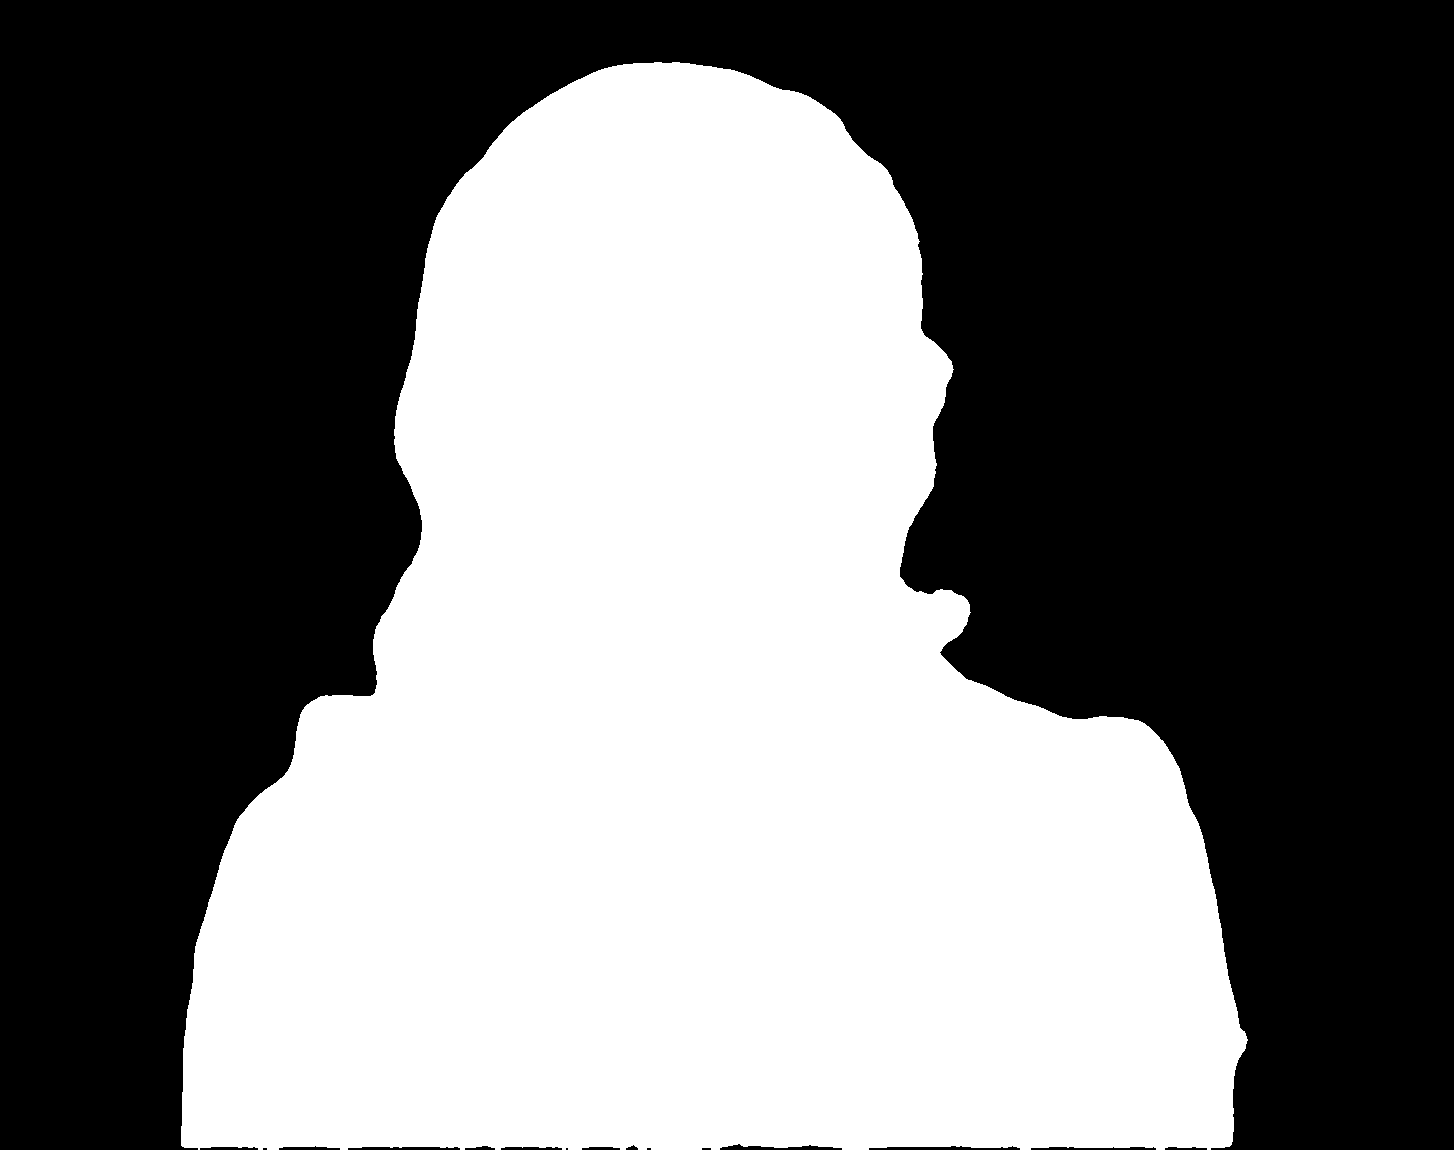

In [20]:
display(mask_img)
display(mask_img_2)

In [13]:
import torchvision.transforms.functional as TF

In [14]:
img_1_tensor = TF.to_tensor(img_1).cuda()
img_2_tensor = TF.to_tensor(img_2).cuda()

In [15]:
out = harness([img_1_tensor, img_2_tensor], "Person")

torch.Size([1008, 1008]) torch.Size([1372, 866])
torch.Size([1008, 1008]) torch.Size([1454, 1150])


In [16]:
mask_img = Image.fromarray(out[1].masks[0].cpu().numpy())

(1372, 866)


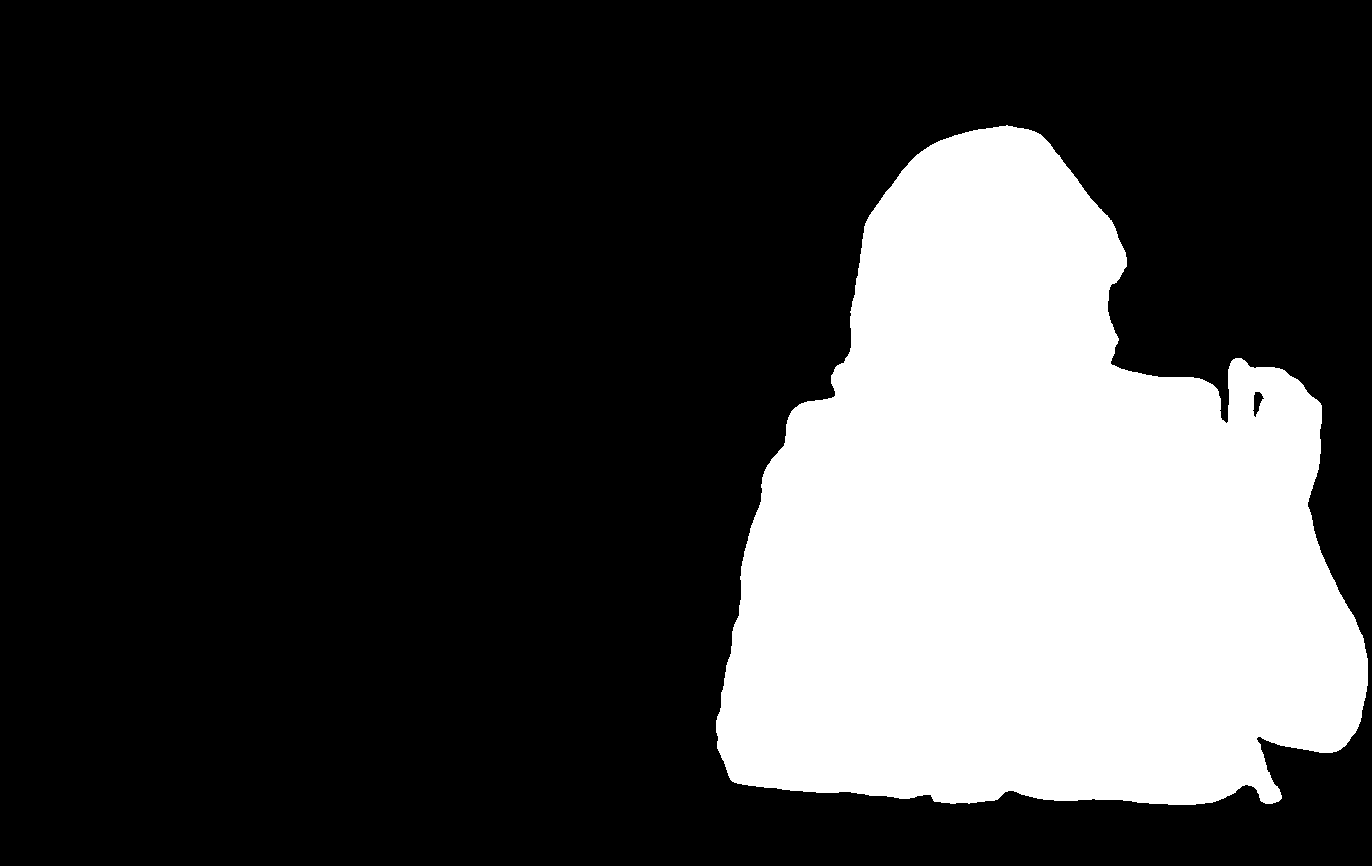

In [23]:
print(mask_img.size)
display(mask_img)